In [2]:
import pandas as pd

df = pd.read_csv("C:/Users/LENOVO/OneDrive/Desktop/Real Time Fraud Detection/Dataset/Raw/bs140513_032310.csv")

print(df.describe())

print(df.groupby("fraud")["amount"].describe())

category_fraud = df.groupby("category")["fraud"].agg(
    total_transactions="count",
    fraud_cases="sum",
    fraud_rate="mean"
).sort_values(by="fraud_rate", ascending=False)

# The fraud is represented by Binary 1 
# So adding up 1 gives up the value while adding up 0 gives us nothing in return 
 
print(category_fraud)

gender_fraud = df.groupby("gender")["fraud"].mean()*100
print(f"\n {gender_fraud}")

age_fraud = df.groupby("age")["fraud"].mean() * 100
print(f"\n {age_fraud}")


                step         amount          fraud
count  594643.000000  594643.000000  594643.000000
mean       94.986827      37.890135       0.012108
std        51.053632     111.402831       0.109369
min         0.000000       0.000000       0.000000
25%        52.000000      13.740000       0.000000
50%        97.000000      26.900000       0.000000
75%       139.000000      42.540000       0.000000
max       179.000000    8329.960000       1.000000
          count        mean         std   min     25%      50%       75%  \
fraud                                                                      
0      587443.0   31.847230   31.470876  0.00   13.59   26.610   41.8950   
1        7200.0  530.926551  835.587112  0.03  159.98  319.175  548.9775   

           max  
fraud           
0      2144.86  
1      8329.96  
                         total_transactions  fraud_cases  fraud_rate
category                                                            
'es_leisure'                  

## Visualization of the dataset

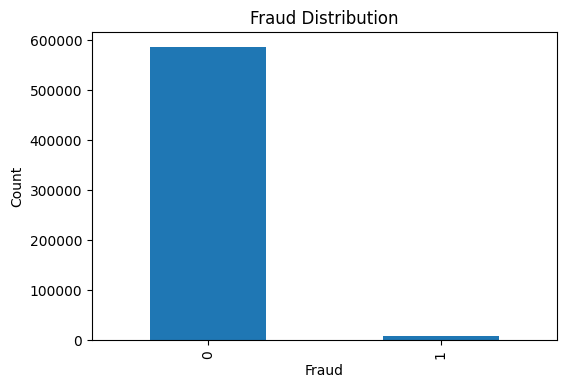

In [3]:
import matplotlib.pyplot as plt

fraud_counts = df["fraud"].value_counts()

plt.figure(figsize=(6,4))
fraud_counts.plot(kind="bar")

plt.title("Fraud Distribution")
plt.xlabel("Fraud")
plt.ylabel("Count")

plt.show()

## Transaction Amount Distribution

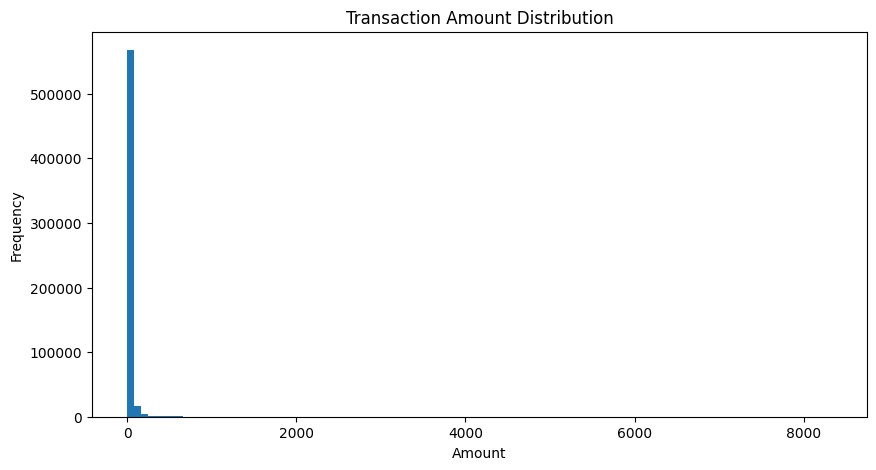

In [4]:
plt.figure(figsize=(10,5))

plt.hist(df["amount"], bins=100)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

## Fraud Amount Distribution

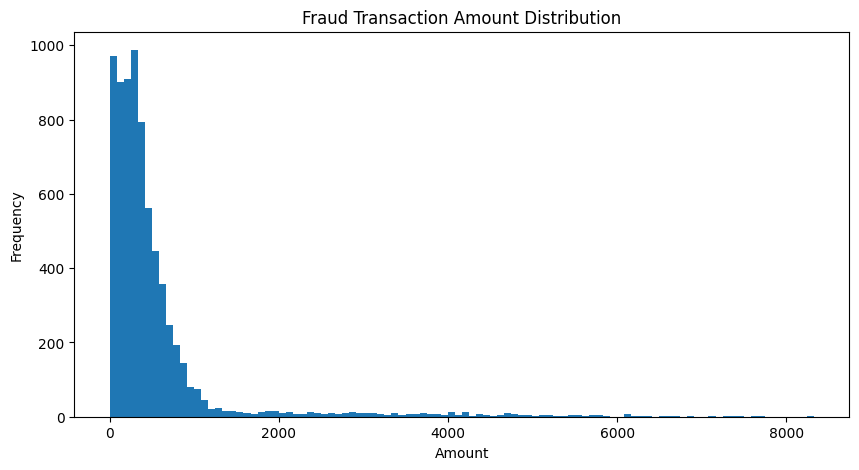

In [5]:
fraud_df = df[df["fraud"] == 1]

plt.figure(figsize=(10,5))

plt.hist(fraud_df["amount"], bins=100)

plt.title("Fraud Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

### Top Fraud Categories

In [6]:
top_fraud_categories = (
    df[df["fraud"] == 1]["category"]
    .value_counts()
)

print(top_fraud_categories)

category
'es_sportsandtoys'         1982
'es_health'                1696
'es_wellnessandbeauty'      718
'es_travel'                 578
'es_hotelservices'          548
'es_leisure'                474
'es_home'                   302
'es_hyper'                  280
'es_otherservices'          228
'es_tech'                   158
'es_barsandrestaurants'     120
'es_fashion'                116
Name: count, dtype: int64


In [7]:
# Verifying ZipCode uniqueness

print(df["zipcodeOri"].nunique())
print(df["zipMerchant"].nunique())

# The Output of both is 1 so they are useless

1
1
